In [40]:
from matplotlib import pyplot as plt
import matplotlib
import scipy

In [41]:
import numpy as np

In [42]:
from urllib.request import urlretrieve

In [44]:
urlretrieve('http://das.sdss.org/va/qsocat/dr7qso.dat', './dr7qso.dat')

('./dr7qso.dat', <http.client.HTTPMessage at 0x26febe91130>)

In [45]:
z=np.loadtxt('dr7qso.dat',skiprows=80,usecols=3)
z=z[:10000]
print(z)


[1.8246 1.8373 1.1985 ... 1.7592 1.4597 1.8671]


[1.8246 1.8373 1.1985 ... 1.7592 1.4597 1.8671]


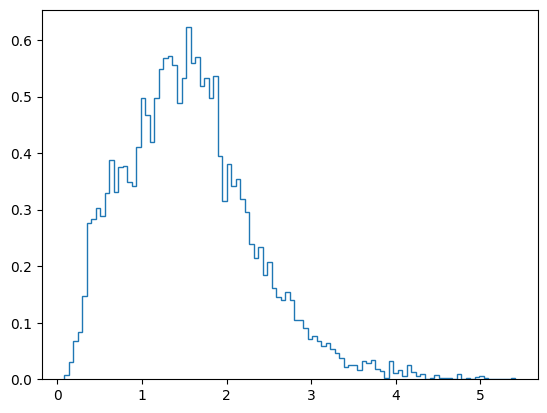

In [46]:
print(z)
matplotlib.rcParams['text.usetex'] = False
counts, bins=np.histogram(z, bins=100, density="True")
plt.stairs(counts,bins)

(array([0.03709942, 0.11129825, 0.25557376, 0.32152828, 0.31328397,
        0.33801691, 0.36274986, 0.34213907, 0.46168164, 0.41633791,
        0.49878105, 0.69664461, 0.54412479, 0.43694869, 0.56473557,
        0.61007931, 0.4946589 , 0.4946589 , 0.30916181, 0.33801691,
        0.3586277 , 0.3009175 , 0.25969592, 0.23084082, 0.24320729,
        0.12778688, 0.14839767, 0.11542041, 0.11129825, 0.10717609,
        0.10717609, 0.0288551 , 0.02473294, 0.03297726, 0.02473294,
        0.02061079, 0.02473294, 0.02061079, 0.00824431, 0.01236647,
        0.01236647, 0.01236647, 0.00412216, 0.        , 0.        ,
        0.        , 0.        , 0.00824431, 0.        , 0.00412216]),
 array([0.14587474, 0.242989  , 0.34010325, 0.43721751, 0.53433177,
        0.63144602, 0.72856028, 0.82567453, 0.92278879, 1.01990305,
        1.1170173 , 1.21413156, 1.31124581, 1.40836007, 1.50547432,
        1.60258858, 1.69970284, 1.79681709, 1.89393135, 1.9910456 ,
        2.08815986, 2.18527412, 2.28238837, 2.

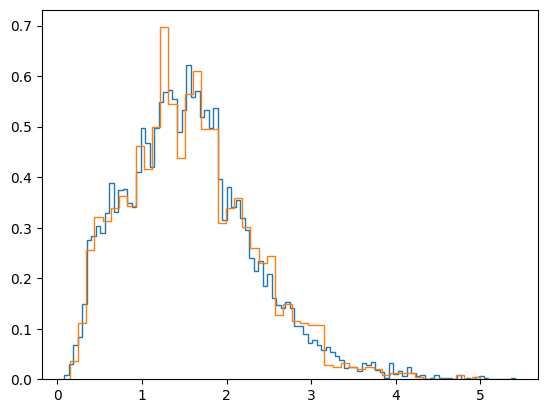

In [51]:
counts, bins=np.histogram(z, bins=100, density="True")
plt.stairs(counts,bins)

disth = scipy.stats.rv_histogram((counts,bins))
maxh=1

N = 100000
a = np.random.uniform(-10, 30, N) 
b = np.random.uniform(0, maxh, N) 


good = a[b<=disth.pdf(a)]

plt.hist(good, bins=50, density=True,histtype='step')


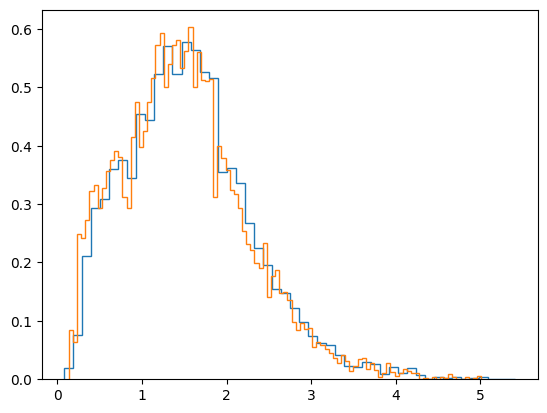

In [50]:
plt.hist(z,bins=50,histtype='step',density=True,label='original data');

# make a simple histogram object
counts, bins = np.histogram(z, bins=50, density=True)
bin_mids = (bins[1:] + bins[:-1]) / 2 # mid location of bins
 
simple_cdf = np.cumsum(counts) / np.sum(counts) # very simply cumulative sum

# set up an interpolation of the inverse cumulative distribution
tck = scipy.interpolate.interp1d(simple_cdf, bin_mids)

# sample uniformly along the cumulative distribution, and interpolate
# little hack to make sure no points are generated outside interpolation range.
# not ideal
u = np.random.uniform(min(simple_cdf),max(simple_cdf), 10000) 
x_sample = tck(u)

plt.hist(x_sample, bins=100, density=True, histtype='step',label='cloned data');


In [53]:
import astropy


In [54]:
z_vals = np.linspace(0,5,100)
comvol = astropy.cosmology.Planck18.differential_comoving_volume(z_vals).value

(array([0.01875012, 0.07593797, 0.21187632, 0.29343933, 0.30937693,
        0.36000225, 0.37593985, 0.34500216, 0.45375284, 0.44344027,
        0.52312827, 0.57000356, 0.52219076, 0.57750361, 0.56437853,
        0.52594079, 0.51656573, 0.35531472, 0.36093976, 0.3365646 ,
        0.26812668, 0.2240639 , 0.19593872, 0.15375096, 0.14718842,
        0.12281327, 0.09750061, 0.07406296, 0.06281289, 0.05906287,
        0.04218776, 0.02343765, 0.02062513, 0.03000019, 0.02625016,
        0.00843755, 0.02156263, 0.01125007, 0.01875012, 0.00750005,
        0.00093751, 0.00468753, 0.00187501, 0.00468753, 0.00093751,
        0.00187501, 0.00375002, 0.        , 0.        , 0.00093751]),
 array([0.0802  , 0.186866, 0.293532, 0.400198, 0.506864, 0.61353 ,
        0.720196, 0.826862, 0.933528, 1.040194, 1.14686 , 1.253526,
        1.360192, 1.466858, 1.573524, 1.68019 , 1.786856, 1.893522,
        2.000188, 2.106854, 2.21352 , 2.320186, 2.426852, 2.533518,
        2.640184, 2.74685 , 2.853516, 2.960182

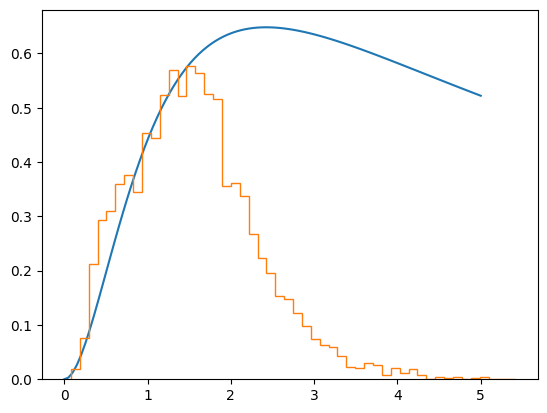

In [55]:
z1 = np.linspace(0,5,100)
plt.plot(z1,comvol/6.5e10)

plt.hist(z,bins=50,histtype='step',density=True)